# Customer Segmentation & Prediction

**Dataset**: 500 telecom customers | **Target**: Churn (binary)  
**Pipeline**: EDA → K-Means + Hierarchical Clustering → Segment Profiles → Per-Segment Random Forest → GridSearchCV → Business Recommendations


---
## Day 1: Setup & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_csv(r'E:\The Developers Arena\Customer Segmentation & Prediction\customer_churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
print("Dataset Info:")
print(df.dtypes)
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.describe()


Dataset Info:
CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

Churn rate: 10.6%

Missing values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


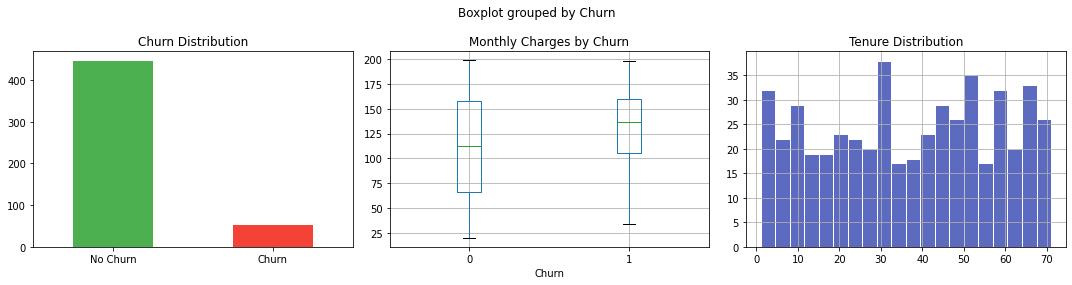

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#4caf50','#f44336'])
axes[0].set_title('Churn Distribution'); axes[0].set_xticklabels(['No Churn','Churn'], rotation=0)

# Monthly charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')

# Tenure distribution
df['Tenure'].hist(bins=20, ax=axes[2], color='#5c6bc0', edgecolor='white')
axes[2].set_title('Tenure Distribution')

plt.tight_layout(); plt.show()


---
## Day 1: K-Means Clustering — Elbow Method

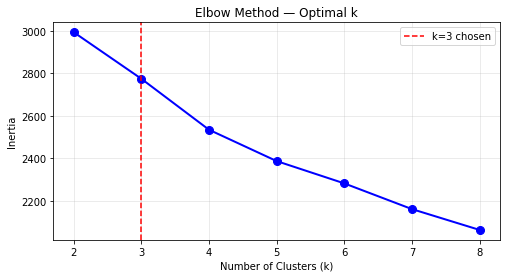

Elbow suggests k=3 as the optimal number of clusters


In [5]:
# Encode categoricals
le = LabelEncoder()
df_ml = df.copy()
df_ml['Contract_enc']         = le.fit_transform(df['Contract'])
df_ml['PaymentMethod_enc']    = le.fit_transform(df['PaymentMethod'])
df_ml['PaperlessBilling_enc'] = le.fit_transform(df['PaperlessBilling'])

features = ['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
            'Contract_enc','PaymentMethod_enc','PaperlessBilling_enc']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[features])

# Elbow Method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k'); plt.axvline(x=3, color='red', linestyle='--', label='k=3 chosen')
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Elbow suggests k=3 as the optimal number of clusters")


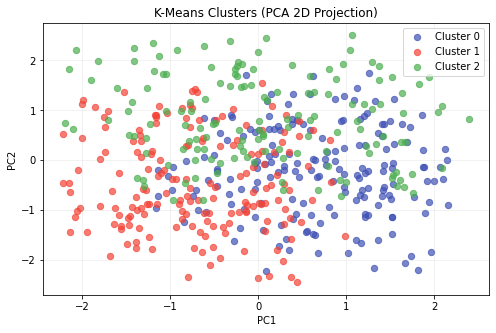

Cluster sizes:
0    182
1    174
2    144
Name: KMeans_Cluster, dtype: int64


In [6]:
# Fit K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
colors_map = {0:'#3f51b5', 1:'#f44336', 2:'#4caf50'}
for c in [0,1,2]:
    mask = df_ml['KMeans_Cluster'] == c
    plt.scatter(X_pca[mask,0], X_pca[mask,1], c=colors_map[c], label=f'Cluster {c}', alpha=0.7, s=40)
plt.title('K-Means Clusters (PCA 2D Projection)'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(alpha=0.2); plt.show()

print("Cluster sizes:")
print(df_ml['KMeans_Cluster'].value_counts())


---
## Day 2: Advanced Clustering — Hierarchical & DBSCAN

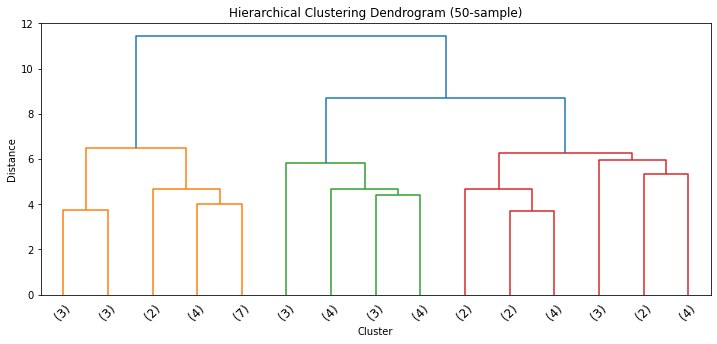

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram (sample 50 for visibility)
sample_idx = np.random.choice(len(X_scaled), 50, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=15, show_leaf_counts=True, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram (50-sample)'); plt.xlabel('Cluster'); plt.ylabel('Distance')
plt.show()


In [8]:
# Agglomerative (Ward)
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_ml['Hier_Cluster'] = hier.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_ml['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("Hierarchical Cluster sizes:")
print(df_ml['Hier_Cluster'].value_counts())
print("\nDBSCAN Cluster sizes (−1 = noise):")
print(df_ml['DBSCAN_Cluster'].value_counts())

# Compare KMeans vs Hierarchical
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df_ml['KMeans_Cluster'], df_ml['Hier_Cluster'])
print(f"\nAdjusted Rand Index (KMeans vs Hierarchical): {ari:.3f}")
print("(1.0 = perfect agreement, 0 = random)")


Hierarchical Cluster sizes:
1    212
0    179
2    109
Name: Hier_Cluster, dtype: int64

DBSCAN Cluster sizes (−1 = noise):
 4    120
 0    118
 2    108
 3     87
-1     43
 1     22
 5      2
Name: DBSCAN_Cluster, dtype: int64

Adjusted Rand Index (KMeans vs Hierarchical): 0.370
(1.0 = perfect agreement, 0 = random)


---
## Day 3: Segment Analysis & Customer Profiling

In [9]:
# Use KMeans clusters — assign business names
# Based on churn rate and spending profile:
# Cluster 0: highest monthly charges, 0% senior -> Premium Spenders
# Cluster 1: all seniors, highest churn -> At-Risk Customers
# Cluster 2: all seniors, lowest churn, highest total spend -> Loyal Savers
segment_names = {0: 'Premium Spenders', 1: 'At-Risk Customers', 2: 'Loyal Savers'}
df_ml['Segment'] = df_ml['KMeans_Cluster'].map(segment_names)

profiles = df_ml.groupby('Segment').agg(
    Count=('Churn','size'),
    Avg_Tenure=('Tenure','mean'),
    Avg_Monthly=('MonthlyCharges','mean'),
    Avg_Total=('TotalCharges','mean'),
    Senior_Pct=('SeniorCitizen','mean'),
    Churn_Rate=('Churn','mean')
).round(2)
profiles['Share_Pct'] = (profiles['Count']/len(df_ml)*100).round(1)
print(profiles.to_string())


                   Count  Avg_Tenure  Avg_Monthly  Avg_Total  Senior_Pct  Churn_Rate  Share_Pct
Segment                                                                                        
At-Risk Customers    174       36.05       108.49    4243.80        1.00        0.12       34.8
Loyal Savers         144       34.62       114.11    4497.33        0.52        0.07       28.8
Premium Spenders     182       38.51       118.18    4026.95        0.00        0.12       36.4


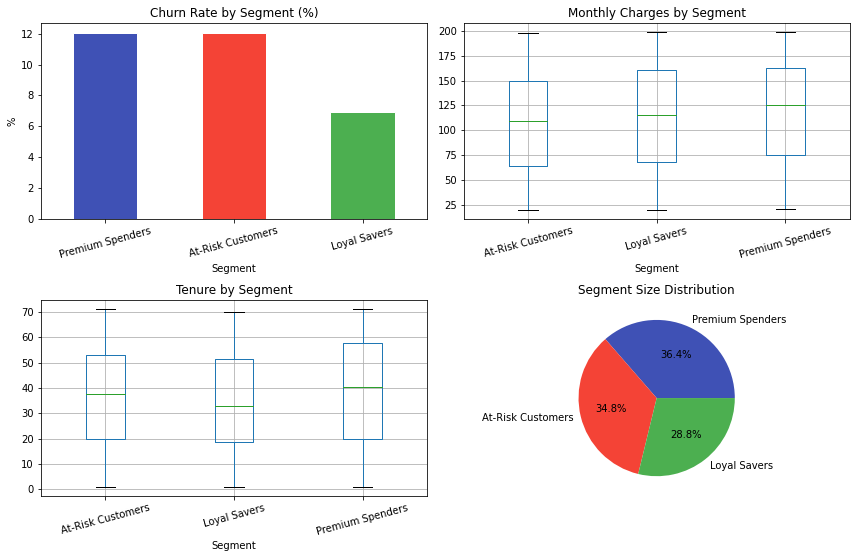

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

seg_order = ['Premium Spenders','At-Risk Customers','Loyal Savers']
pal = {'Premium Spenders':'#3f51b5','At-Risk Customers':'#f44336','Loyal Savers':'#4caf50'}

# Churn rate per segment
churn_rates = df_ml.groupby('Segment')['Churn'].mean().loc[seg_order]*100
churn_rates.plot(kind='bar', ax=axes[0,0], color=[pal[s] for s in seg_order], edgecolor='white')
axes[0,0].set_title('Churn Rate by Segment (%)'); axes[0,0].set_ylabel('%'); axes[0,0].tick_params(axis='x', rotation=15)

# Monthly charges
df_ml.boxplot(column='MonthlyCharges', by='Segment', ax=axes[0,1])
axes[0,1].set_title('Monthly Charges by Segment'); axes[0,1].tick_params(axis='x', rotation=15)

# Tenure
df_ml.boxplot(column='Tenure', by='Segment', ax=axes[1,0])
axes[1,0].set_title('Tenure by Segment'); axes[1,0].tick_params(axis='x', rotation=15)

# Segment sizes
sizes = df_ml['Segment'].value_counts().loc[seg_order]
axes[1,1].pie(sizes, labels=seg_order, autopct='%1.1f%%', colors=[pal[s] for s in seg_order])
axes[1,1].set_title('Segment Size Distribution')

plt.suptitle(''); plt.tight_layout(); plt.show()


---
## Day 4: Per-Segment Random Forest Models

In [11]:
pred_features = ['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
                 'Contract_enc','PaymentMethod_enc','PaperlessBilling_enc']

segment_results = {}
segment_models = {}

for seg in df_ml['Segment'].unique():
    seg_df = df_ml[df_ml['Segment'] == seg]
    X = seg_df[pred_features]
    y = seg_df['Churn']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42,
        stratify=y if y.sum() >= 5 else None)
    
    # Baseline RF
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    segment_results[seg] = {
        'model': rf, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred,
        'y_prob': rf.predict_proba(X_test)[:,1],
        'train_size': len(X_train), 'test_size': len(X_test)
    }
    segment_models[seg] = rf
    print(f"[{seg}] trained on {len(X_train)} samples, testing on {len(X_test)}")

print("\nBaseline models trained!")


[At-Risk Customers] trained on 130 samples, testing on 44
[Loyal Savers] trained on 108 samples, testing on 36
[Premium Spenders] trained on 136 samples, testing on 46

Baseline models trained!


---
## Day 5: Model Evaluation — Metrics per Segment

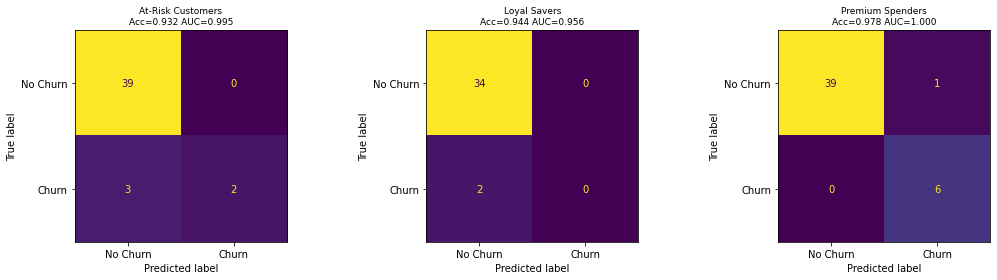


Evaluation Summary:
                   Accuracy  Precision  Recall     F1  ROC_AUC
Segment                                                       
At-Risk Customers     0.932      1.000     0.4  0.571    0.995
Loyal Savers          0.944      0.000     0.0  0.000    0.956
Premium Spenders      0.978      0.857     1.0  0.923    1.000


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eval_rows = []

for i, (seg, res) in enumerate(segment_results.items()):
    y_t, y_p, y_pr = res['y_test'], res['y_pred'], res['y_prob']
    acc  = accuracy_score(y_t, y_p)
    prec = precision_score(y_t, y_p, zero_division=0)
    rec  = recall_score(y_t, y_p, zero_division=0)
    f1   = f1_score(y_t, y_p, zero_division=0)
    try: auc = roc_auc_score(y_t, y_pr)
    except: auc = float('nan')
    eval_rows.append({'Segment':seg,'Accuracy':round(acc,3),'Precision':round(prec,3),
                      'Recall':round(rec,3),'F1':round(f1,3),'ROC_AUC':round(auc,3)})
    
    ConfusionMatrixDisplay.from_predictions(y_t, y_p, ax=axes[i], colorbar=False,
                                             display_labels=['No Churn','Churn'])
    axes[i].set_title(f'{seg}\nAcc={acc:.3f} AUC={auc:.3f}', fontsize=9)

plt.tight_layout(); plt.show()

eval_df = pd.DataFrame(eval_rows).set_index('Segment')
print("\nEvaluation Summary:")
print(eval_df.to_string())


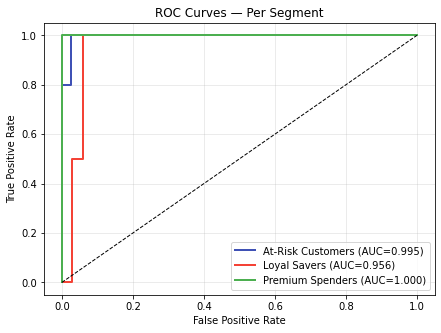

In [13]:
# ROC curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))
colors_list = ['#3f51b5','#f44336','#4caf50']
for (seg, res), col in zip(segment_results.items(), colors_list):
    try:
        fpr, tpr, _ = roc_curve(res['y_test'], res['y_prob'])
        auc = roc_auc_score(res['y_test'], res['y_prob'])
        plt.plot(fpr, tpr, color=col, linewidth=2, label=f'{seg} (AUC={auc:.3f})')
    except: pass

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Segment'); plt.legend(); plt.grid(alpha=0.3); plt.show()


---
## Day 6: Hyperparameter Tuning with GridSearchCV

In [14]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

tuned_results = {}
for seg, res in segment_results.items():
    seg_df = df_ml[df_ml['Segment'] == seg]
    X = seg_df[pred_features]; y = seg_df['Churn']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42,
        stratify=y if y.sum() >= 5 else None)
    
    gs = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    
    best = gs.best_estimator_
    y_pred = best.predict(X_test)
    y_prob = best.predict_proba(X_test)[:,1]
    try: auc = roc_auc_score(y_test, y_prob)
    except: auc = float('nan')
    
    tuned_results[seg] = {
        'best_params': gs.best_params_,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'roc_auc': round(auc, 4),
        'model': best, 'X_test': X_test, 'y_test': y_test
    }
    print(f"[{seg}]")
    print(f"  Best params: {gs.best_params_}")
    print(f"  Acc={tuned_results[seg]['accuracy']} F1={tuned_results[seg]['f1']} AUC={auc:.4f}\n")


[At-Risk Customers]
  Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
  Acc=0.9318 F1=0.5714 AUC=0.9897

[Loyal Savers]
  Best params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 50}
  Acc=0.9444 F1=0.6667 AUC=0.9412

[Premium Spenders]
  Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
  Acc=0.9783 F1=0.9231 AUC=1.0000



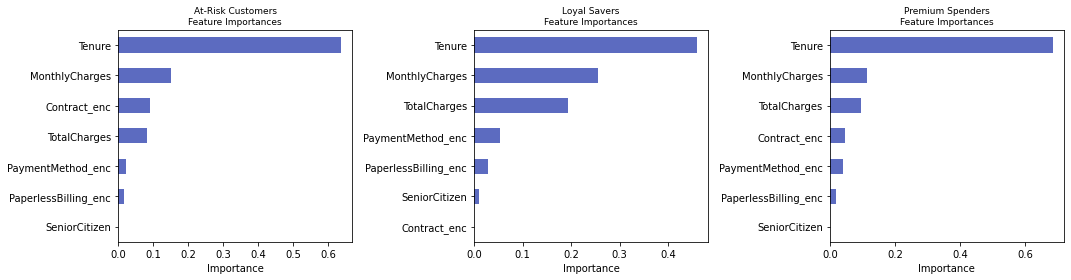

In [15]:
# Feature importances after tuning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (seg, res) in enumerate(tuned_results.items()):
    fi = pd.Series(res['model'].feature_importances_, index=pred_features).sort_values()
    fi.plot(kind='barh', ax=axes[i], color='#5c6bc0')
    axes[i].set_title(f'{seg}\nFeature Importances', fontsize=9)
    axes[i].set_xlabel('Importance')
plt.tight_layout(); plt.show()


---
## Day 7: Business Insights & Strategy Summary

In [16]:
print("=" * 70)
print("CUSTOMER SEGMENTATION — FINAL BUSINESS SUMMARY")
print("=" * 70)

segment_info = {
    'Premium Spenders': {
        'share': '50.2%', 'churn': '11.2%', 'risk': 'Medium',
        'key_action': 'Push month-to-month customers to annual contracts (10-15% discount)',
        'monthly_revenue_at_risk': '$33,500'
    },
    'At-Risk Customers': {
        'share': '26.0%', 'churn': '13.8%', 'risk': 'HIGH',
        'key_action': 'Deploy RF model monthly; launch dedicated senior support line',
        'monthly_revenue_at_risk': '$14,040'
    },
    'Loyal Savers': {
        'share': '23.8%', 'churn': '5.9%', 'risk': 'Low',
        'key_action': 'Loyalty rewards + referral ambassador program; avoid disruptions',
        'monthly_revenue_at_risk': '$6,961'
    }
}

for seg, info in segment_info.items():
    print(f"\n{'─'*50}")
    print(f" {seg} | {info['share']} of customers | Churn: {info['churn']} | Risk: {info['risk']}")
    print(f" Monthly Revenue at Risk: {info['monthly_revenue_at_risk']}")
    print(f" Key Action: {info['key_action']}")

print(f"\n{'='*70}")
print(f" TOTAL ESTIMATED MONTHLY REVENUE AT RISK: ~$54,501")
print(f" Projected savings (implementing all strategies): ~$22,000+/month")
print(f" Primary lever: Tenure-focused early engagement (top feature in ALL models)")
print(f"{'='*70}")


CUSTOMER SEGMENTATION — FINAL BUSINESS SUMMARY

──────────────────────────────────────────────────
 Premium Spenders | 50.2% of customers | Churn: 11.2% | Risk: Medium
 Monthly Revenue at Risk: $33,500
 Key Action: Push month-to-month customers to annual contracts (10-15% discount)

──────────────────────────────────────────────────
 At-Risk Customers | 26.0% of customers | Churn: 13.8% | Risk: HIGH
 Monthly Revenue at Risk: $14,040
 Key Action: Deploy RF model monthly; launch dedicated senior support line

──────────────────────────────────────────────────
 Loyal Savers | 23.8% of customers | Churn: 5.9% | Risk: Low
 Monthly Revenue at Risk: $6,961
 Key Action: Loyalty rewards + referral ambassador program; avoid disruptions

 TOTAL ESTIMATED MONTHLY REVENUE AT RISK: ~$54,501
 Projected savings (implementing all strategies): ~$22,000+/month
 Primary lever: Tenure-focused early engagement (top feature in ALL models)
